---
## 🎁 가산점 신청 (선택)

가산점을 받으려면 아래 항목 중 시도한 것을 **체크**하고, **해당 코드 셀 번호**를 적어주세요.
신청하지 않은 항목은 채점하지 않습니다.

### A. 알고리즘의 다양성
- 모델 개발에 시도된 기계학습 알고리즘의 종류를 기준으로 판단

### B. Hyperparameter 탐색의 다양성
- 각 기계학습 알고리즘에서 유의미한 하이퍼파라미터들을 최적화했는지 확인

### C. 모델 성능 평가
- 모델 성능 평가에 사용된 지표의 다양성 (지수를 종합적으로 판단해서 최종 모델을 선택해야 함)

### D. 모델 개발 과정 시각화 및 설명
- 실험 과정에 대한 시각화 (learning curve)
- 모델 성능에 대한 시각화
- 코드에 대한 설명



# 기말고사 Template 2 — Machine Learning Model Pipeline

**이름:** _____육건우_____ &nbsp; **학번:** _______20251284_______ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **5. 모델 학습 알고리즘** | 15점 | 기계학습 알고리즘을 몇 종 사용했는지? |
| **6. Hyperparameter 탐색** | 15점 | 기계학습 알고리즘 별로 hyperparameter를 어떻게 최적화 시켰는지? |
| **7. 결과 정리 & 시각화** | 15점 | 최종 모델을 선택한 기준 및 모델 개발 과정을 설명하는 시각화 자료 |
| **8. 모델 저장 & 새 분자 예측** | 5점 | 모델을 저장한 후, 새로운 분자 구조를 예측할 수 있도록 정리. |

## 📁 입력 / 출력
- **입력**: Template 1에서 만든 `final_dataset_descriptors.csv`
- **출력**: 
  - `experiment_results.csv` — 모든 실험 결과 표
  - `experiment_best.csv` — 모델별 베스트만
  - `model_best.joblib` — 최고 모델 저장 파일 (features + scaler + model)

---

In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install xgboost lightgbm


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 종별(Rat/Mouse) 독성 예측 머신러닝 파이프라인 구축

## 1. 프로젝트 개요
화합물의 분자 구조 데이터(RDKit Descriptor)를 활용하여 **종(Species: Rat, Mouse)**에 따른 발암성 독성을 예측하는 독립적 머신러닝 파이프라인을 구축하는 것을 목표로 한다.

성별 외에 생물학적 종(Species)의 차이에만 집중함으로써 랫(Rat)과 마우스(Mouse) 각각의 데이터 환경에 최적화된 하이퍼파라미터를 조정하고 모델의 최종 정확도를 극대화하고자 한다.

* **대상 데이터**: `cancer_descriptors.csv`
* **예측 타겟**: label
* **핵심 전략**:
    1. 전체 데이터를 `Is_Rat` 기준에 따라 **Rat 데이터셋**과 **Mouse 데이터셋**으로 완전 분리
    2. 데이터 불균형을 고려하여 층화 추출(`stratify=y`) 방식을 적용한 Train/Test (8:2) 분할
    3. 각 종별 데이터셋에 대해 4종의 머신러닝 알고리즘 독립적 적용
    4. 5-Fold 교차 검증 및 Hyperparameter 튜닝 통합 수행

## 2. 종별 모델링 수행 및 교차검증 결과 요약

각 종별(Rat / Mouse) 최적 모델의 validation 및 test 성능 비교 및 시각화

In [3]:
import pandas as pd
import numpy as np
# 템플릿 1의 최종 결과물 로드
df = pd.read_csv("cancer_descriptors.csv")

df

,Chemical_Name,SMILES,Is_Rat,Is_Male,label,MolWt,LogP,NumHDonors,NumHAcceptors,FP_0,...,FP_22,FP_23,FP_24,FP_25,FP_26,FP_27,FP_28,FP_29,FP_30,FP_31
0,Divinylbenzene,*C=C.C=Cc1ccccc1,0,1,0,131.198,3.0088,0,0,1,...,1,0,0,0,0,0,0,1,0,0
1,Divinylbenzene,*C=C.C=Cc1ccccc1,1,0,0,131.198,3.0088,0,0,1,...,1,0,0,0,0,0,0,1,0,0
2,Bromoform,BrC(Br)Br,0,0,0,252.731,2.4547,0,0,0,...,0,0,1,0,0,0,0,0,1,0
3,Bromoform,BrC(Br)Br,0,1,0,252.731,2.4547,0,0,0,...,0,0,1,0,0,0,0,0,1,0
4,Bromoform,BrC(Br)Br,1,0,1,252.731,2.4547,0,0,0,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,Lead dimethyldithiocarbamate,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Pb+2],1,0,0,447.644,0.3788,0,4,0,...,0,0,1,0,0,0,0,0,1,0
1678,Lead dimethyldithiocarbamate,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Pb+2],1,1,0,447.644,0.3788,0,4,0,...,0,0,1,0,0,0,0,0,1,0
1679,Ziram,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Zn+2],0,1,0,305.834,0.7571,0,4,0,...,0,0,1,0,0,0,0,0,0,0
1680,Ziram,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Zn+2],1,0,0,305.834,0.7571,0,4,0,...,0,0,1,0,0,0,0,0,0,0


# 종별 독성 예측 머신러닝
- Rat은 Rat끼리, Mouse는 Mouse끼리 데이터를 분리해 학습시킬 예정.
- 종별로 묶었을 때 성별이 달라 정제되지 않은 데이터, Smiles가 중복될 경우 데이터 삭제

In [4]:
# 1. 동물 종(Species) 필터링에 따른 데이터 분리
# Is_Rat 컬럼 값이 1이면 Rat, 0이면 Mouse 데이터로 가져옵니다.
df_rat_raw = df[df['Is_Rat'] == 1].copy()
df_mouse_raw = df[df['Is_Rat'] == 0].copy()

print("--- 1차 분리 직후 데이터 개수 ---")
print("Rat 데이터 개수: " + str(len(df_rat_raw)))
print("Mouse 데이터 개수: " + str(len(df_mouse_raw)))

# 2. 각 종별 데이터셋 내에서 SMILES 분자 구조 기준 중복 제거 (데이터 누수 방지 포인트)
# 종을 나누었을 때 내부 조건에 따라 동일 분자가 중복 존재할 수 있으므로 최종 정리합니다.
df_rat = df_rat_raw.drop_duplicates(subset=['SMILES'], keep='first').reset_index(drop=True)
df_mouse = df_mouse_raw.drop_duplicates(subset=['SMILES'], keep='first').reset_index(drop=True)

print("--- 중복 제거 후 최종 유효 데이터 개수 ---")
print("최종 Rat 데이터 개수: " + str(len(df_rat)))
print("최종 Mouse 데이터 개수: " + str(len(df_mouse)))

--- 1차 분리 직후 데이터 개수 ---
Rat 데이터 개수: 835
Mouse 데이터 개수: 847
--- 중복 제거 후 최종 유효 데이터 개수 ---
최종 Rat 데이터 개수: 459
최종 Mouse 데이터 개수: 460


# 분자 구조 Descriptor 추출 및 종별 독립 변수(X), 종속 변수(y) 분리

In [5]:
# 현재 데이터프레임에 어떤 컬럼들이 있는지 앞부분만 확인
print(df.columns.tolist()[:15])

['Chemical_Name', 'SMILES', 'Is_Rat', 'Is_Male', 'label', 'MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'FP_0', 'FP_1', 'FP_2', 'FP_3', 'FP_4', 'FP_5']


In [12]:
# 1. 대문자 'FP_'로 시작하는 컬럼명을 동적으로 추출
feature_cols = [col for col in df.columns if col.startswith('FP_')]

print("--- 추출된 Feature 컬럼 개수 확인 ---")
print("총 Feature 개수: " + str(len(feature_cols)))
print("추출된 컬럼명 일부:", feature_cols[:5]) # 잘 추출되었는지 앞부분 확인

# 2. Rat 데이터셋 X, y 분리
X_rat = df_rat[feature_cols]
y_rat = df_rat['label']

# 3. Mouse 데이터셋 X, y 분리
X_mouse = df_mouse[feature_cols]
y_mouse = df_mouse['label']

print("--- 종별 X, y 분리 결과 (Shape)---")
print("X_rat shape: " + str(X_rat.shape) + " | y_rat shape: " + str(y_rat.shape))
print("X_mouse shape: " + str(X_mouse.shape) + " | y_mouse shape: " + str(y_mouse.shape))

--- 추출된 Feature 컬럼 개수 확인 ---
총 Feature 개수: 32
추출된 컬럼명 일부: ['FP_0', 'FP_1', 'FP_2', 'FP_3', 'FP_4']
--- 종별 X, y 분리 결과 (Shape)---
X_rat shape: (459, 32) | y_rat shape: (459,)
X_mouse shape: (460, 32) | y_mouse shape: (460,)


# Train/Test 데이터셋 분할

1. **랫(Rat) 데이터셋 분할**: `X_rat`와 `y_rat`를 8:2 비율로 분할한다. 이때 `stratify=y_rat`를 부여하여 랫 데이터 내의 독성 분포 비율을 고르게 분배한다.
2. **마우스(Mouse) 데이터셋 분할**: 동일하게 `X_mouse`와 `y_mouse`를 8:2 비율로 분할한다. `stratify=y_mouse` 를 부여하여 마우스 데이터 내의 독성 분포 비율을 고르게 분배한다
3. **재현성 확보**: 실험의 흐름이 매번 바뀌지 않고 동일한 결과를 유지할 수 있도록 난수 고정 파라미터(`random_state=42`)를 설정한다.
4. **분포 무결성 검증**: 분할 직후 `.value_counts(normalize=True)`를 출력하여, 학습에 투입될 Train 정답지의 독성 비율이 균일하게 유지되었는지 수치적으로 모니터링한다.

In [13]:
from sklearn.model_selection import train_test_split

# 1. Rat 데이터셋 분할 (Train 80% : Test 20%)
# stratify=y_rat 옵션을 주어 분할 후에도 독성 라벨의 비율이 균일하게 유지되도록 합니다.
X_rat_train, X_rat_test, y_rat_train, y_rat_test = train_test_split(
    X_rat, y_rat, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_rat
)

# 2. Mouse 데이터셋 분할 (Train 80% : Test 20%)
X_mouse_train, X_mouse_test, y_mouse_train, y_mouse_test = train_test_split(
    X_mouse, y_mouse, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_mouse
)

print("--- 랫(Rat) 데이터셋 분할 결과 ---")
print("Train 문제집 크기: " + str(X_rat_train.shape) + " | Test 문제집 크기: " + str(X_rat_test.shape))
print("Train 정답지 비율: \n" + str(y_rat_train.value_counts(normalize=True)))

print("--- 마우스(Mouse) 데이터셋 분할 결과 ---")
print("Train 문제집 크기: " + str(X_mouse_train.shape) + " | Test 문제집 크기: " + str(X_mouse_test.shape))
print("Train 정답지 비율: \n" + str(y_mouse_train.value_counts(normalize=True)))

--- 랫(Rat) 데이터셋 분할 결과 ---
Train 문제집 크기: (367, 32) | Test 문제집 크기: (92, 32)
Train 정답지 비율: 
label
0    0.610354
1    0.389646
Name: proportion, dtype: float64
--- 마우스(Mouse) 데이터셋 분할 결과 ---
Train 문제집 크기: (368, 32) | Test 문제집 크기: (92, 32)
Train 정답지 비율: 
label
0    0.570652
1    0.429348
Name: proportion, dtype: float64


# 다양한 모델학습 알고리즘 생성 

## 확인해본 알고리즘 종류(4가지)
- Random Forest
- XGBoost
- LightGBM
- SVM

독성예측에 유의미한 주요 핑거프린트의 특성을 안정적으로 학습할 수 있는 모델을 찾고자 함.

In [8]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 1. 평가 지표를 한 번에 계산해서 딕셔너리로 반환하는 함수 정의
def evaluate_model_perf(y_true, y_pred, y_prob):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, y_prob)
    }
    # 소수점 4자리로 반올림
    return {k: round(v, 4) for k, v in metrics.items()}

# 2. 베이스라인 모델 정의 (4대 알고리즘)
base_models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'SVM': Pipeline([
        ('scaler', StandardScaler()), 
        ('svm', SVC(probability=True, random_state=42))
    ])
}

# 3. 랫(Rat) 데이터셋 베이스라인 평가
rat_eval_results = {}
for name, model in base_models.items():
    # 사용자의 변수명인 X_rat_train, y_rat_train을 반영
    model.fit(X_rat_train, y_rat_train)
    y_pred = model.predict(X_rat_test)
    y_prob = model.predict_proba(X_rat_test)[:, 1]
    
    rat_eval_results[name] = evaluate_model_perf(y_rat_test, y_pred, y_prob)

df_rat_baseline = pd.DataFrame(rat_eval_results).T

# 4. 마우스(Mouse) 데이터셋 베이스라인 평가
mouse_eval_results = {}
for name, model in base_models.items():
    # 사용자의 변수명인 X_mouse_train, y_mouse_train을 반영
    model.fit(X_mouse_train, y_mouse_train)
    y_pred = model.predict(X_mouse_test)
    y_prob = model.predict_proba(X_mouse_test)[:, 1]
    
    mouse_eval_results[name] = evaluate_model_perf(y_mouse_test, y_pred, y_prob)

df_mouse_baseline = pd.DataFrame(mouse_eval_results).T

# 5. 최종 결과 출력
print("=========================================================================")
print("📊 [Rat 데이터셋] 베이스라인 4대 알고리즘 다각적 성능 비교 표")
print("=========================================================================")
print(df_rat_baseline)
print(" ")
print("=========================================================================")
print("📊 [Mouse 데이터셋] 베이스라인 4대 알고리즘 다각적 성능 비교 표")
print("=========================================================================")
print(df_mouse_baseline)

📊 [Rat 데이터셋] 베이스라인 4대 알고리즘 다각적 성능 비교 표
               Accuracy  Balanced Accuracy  Precision  Recall  F1-Score  \
Random Forest    0.5652              0.494     0.3750  0.1667    0.2308   
XGBoost          0.5543              0.500     0.3913  0.2500    0.3051   
LightGBM         0.5435              0.496     0.3846  0.2778    0.3226   
SVM              0.5870              0.497     0.3750  0.0833    0.1364   

               AUC-ROC  
Random Forest   0.5122  
XGBoost         0.4995  
LightGBM        0.5119  
SVM             0.4757  
 
📊 [Mouse 데이터셋] 베이스라인 4대 알고리즘 다각적 성능 비교 표
               Accuracy  Balanced Accuracy  Precision  Recall  F1-Score  \
Random Forest    0.5978             0.5595     0.5455  0.3077    0.3934   
XGBoost          0.5652             0.5515     0.4865  0.4615    0.4737   
LightGBM         0.6196             0.6055     0.5556  0.5128    0.5333   
SVM              0.5761             0.5440     0.5000  0.3333    0.4000   

               AUC-ROC  
Random Forest   

# 최적 하이퍼파라미터 찾기 및 5-Fold 교차 검증을 통한 모델 최적화

## 1. 하이퍼파라미터 조정 배경 및 문제 인식
앞서 수행한 베이스라인 모델 평가 결과, 주요 평가지표(Accuracy, AUC-ROC 등)들이 **0.4에서 0.7 사이의 중하위권 성능**에 머무르는 한계를 확인함. 그 원인을 다음과 같이 추론함.

1. **라벨 불균형의 누적 효과**: 앞서 확인한 바와 같이 Rat과 Mouse 데이터셋은 약 `6:4` 내외의 불균형 분포를 가짐. 극단적이지는 않지만 트리 기반 알고리즘이 다수 클래스(독성 없음, 0)를 예측하는 방향으로 미세하게 편향되어, 소수 클래스(독성 있음, 1)에 대한 민감도(Sensitivity)가 떨어졌을 가능성 있음.
2. **트리 탐색 깊이 및 학습률의 미조정**: 기본 파라미터(Default) 환경에서는 트리가 지나치게 깊게 자라나(Overfitting) 30여 개의 Morgan Fingerprint 피처 공간을 과도하게 암기했거나, 학습 보폭(`learning_rate`)이 핑거프린트의 희소성(Sparsity)에 맞지 않아 최적의 손실 함수 지점에 도달하지 못했을 수 있음.

이에 따라, 불균형을 극복하고 모델의 순수한 분별력(`AUC-ROC`)을 최고조로 끌어올리기 위해 **GridSearchCV를 통한 정밀 튜닝 전략**을 도입.

---

## 하이퍼파라미터 격리망(Grid) 설정

특히 이번 튜닝에서는 고성능 부스팅 알고리즘인 `LightGBM`과 `XGBoost`를 타겟팅하여 아래와 같은 논리로 파라미터 후보군을 설계했습니다.

* **`scale_pos_weight`: [1, 2, 3]**
    * **선정 이유**: 양성(독성 물질, 1) 데이터에 인위적으로 가중치를 부여하여 모델이 독성 물질을 놓쳤을 때 더 큰 페널티를 받도록 유도.
* **`max_depth`: [3, 5, 7]**
    * **선정 이유**: 32비트 수준의 Fingerprint 피처 수에 비해 데이터의 수(약 450여 개)가 아주 많지는 않음. 트리의 최대 깊이를 3, 5, 7로 제한하여 모델이 과도하게 복잡해지는 것을 막고 복잡도를 제어하여 일반화 성능을 확보.
* **`learning_rate`: [0.01, 0.05, 0.1] & `n_estimators`: [50, 100, 200]**
    * **선정 이유**: 학습 보폭을 촘촘하게 가져갈 때(`learning_rate` 하향) 트리 개수(`n_estimators`)를 늘려가며 손실 함수가 안정적으로 수렴하는 최적의 조합을 찾고자 함.

---

## 검증 및 평가 설계
* **5-Fold 교차 검증 (cv=5)**
* **`scoring='roc_auc'`**

In [20]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import pandas as pd

# 1. 튜닝할 하이퍼파라미터 그리드 정의
lgbm_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'scale_pos_weight': [1, 2, 3]  # 불균형 데이터 극복을 위한 가중치 부여 파라미터!
}

xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'scale_pos_weight': [1, 2, 3]
}

# 2. Rat 데이터셋 튜닝 (LightGBM & XGBoost)
# 과적합을 막기 위해 5-Fold CV를 수행
grid_lgbm_rat = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1), lgbm_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lgbm_rat.fit(X_rat_train, y_rat_train)

grid_xgb_rat = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb_rat.fit(X_rat_train, y_rat_train)

# 3. Mouse 데이터셋 튜닝 (LightGBM & XGBoost)
grid_lgbm_mouse = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1), lgbm_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lgbm_mouse.fit(X_mouse_train, y_mouse_train)

grid_xgb_mouse = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb_mouse.fit(X_mouse_train, y_mouse_train)

print(" ")
print(f" Rat LightGBM 최적 AUC-ROC: {round(grid_lgbm_rat.best_score_, 4)} | 최적 파라미터: {grid_lgbm_rat.best_params_}")
print(f" Rat XGBoost  최적 AUC-ROC: {round(grid_xgb_rat.best_score_, 4)} | 최적 파라미터: {grid_xgb_rat.best_params_}")
print(f" Mouse LightGBM 최적 AUC-ROC: {round(grid_lgbm_mouse.best_score_, 4)} | 최적 파라미터: {grid_lgbm_mouse.best_params_}")
print(f" Mouse XGBoost  최적 AUC-ROC: {round(grid_xgb_mouse.best_score_, 4)} | 최적 파라미터: {grid_xgb_mouse.best_params_}")

 
 Rat LightGBM 최적 AUC-ROC: 0.5244 | 최적 파라미터: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50, 'scale_pos_weight': 2}
 Rat XGBoost  최적 AUC-ROC: 0.5275 | 최적 파라미터: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'scale_pos_weight': 1}
 Mouse LightGBM 최적 AUC-ROC: 0.6355 | 최적 파라미터: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 2}
 Mouse XGBoost  최적 AUC-ROC: 0.6334 | 최적 파라미터: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 2}


In [17]:
# 1. 최적 모델 추출
best_lgbm_rat = grid_lgbm_rat.best_estimator_
best_xgb_rat = grid_xgb_rat.best_estimator_
best_lgbm_mouse = grid_lgbm_mouse.best_estimator_
best_xgb_mouse = grid_xgb_mouse.best_estimator_

# 2. Rat 최종 테스트 데이터 평가
final_rat_results = {
    'LightGBM (Best)': evaluate_model_perf(y_rat_test, best_lgbm_rat.predict(X_rat_test), best_lgbm_rat.predict_proba(X_rat_test)[:, 1]),
    'XGBoost (Best)': evaluate_model_perf(y_rat_test, best_xgb_rat.predict(X_rat_test), best_xgb_rat.predict_proba(X_rat_test)[:, 1])
}

# 3. Mouse 최종 테스트 데이터 평가
final_mouse_results = {
    'LightGBM (Best)': evaluate_model_perf(y_mouse_test, best_lgbm_mouse.predict(X_mouse_test), best_lgbm_mouse.predict_proba(X_mouse_test)[:, 1]),
    'XGBoost (Best)': evaluate_model_perf(y_mouse_test, best_xgb_mouse.predict(X_mouse_test), best_xgb_mouse.predict_proba(X_mouse_test)[:, 1])
}

print("=========================================================================")
print("[Rat 최종 최적화 모델] 독립 테스트 데이터셋 성능 검증 표")
print("=========================================================================")
print(pd.DataFrame(final_rat_results).T)
print("=========================================================================")
print("[Mouse 최종 최적화 모델] 독립 테스트 데이터셋 성능 검증 표")
print("=========================================================================")
print(pd.DataFrame(final_mouse_results).T)

[Rat 최종 최적화 모델] 독립 테스트 데이터셋 성능 검증 표
                 Accuracy  Balanced Accuracy  Precision  Recall  F1-Score  \
LightGBM (Best)    0.5870             0.5119     0.4286  0.1667      0.24   
XGBoost (Best)     0.6087             0.5000     0.0000  0.0000      0.00   

                 AUC-ROC  
LightGBM (Best)   0.5489  
XGBoost (Best)    0.6104  
[Mouse 최종 최적화 모델] 독립 테스트 데이터셋 성능 검증 표
                 Accuracy  Balanced Accuracy  Precision  Recall  F1-Score  \
LightGBM (Best)    0.5000             0.5119     0.4340  0.5897    0.5000   
XGBoost (Best)     0.5435             0.5564     0.4717  0.6410    0.5435   

                 AUC-ROC  
LightGBM (Best)   0.5977  
XGBoost (Best)    0.5977  


## 베이스라인 vs 최적화 모델 성능 비교 및 데이터 과학적 해석

### 1. Mouse 모델: 단순 정확도(Accuracy) 하락과 재현율(Recall) 상승의 트레이드오프
* **현상**: Mouse 데이터셋의 경우 베이스라인 LightGBM(Accuracy: 0.6196) 대비 최종 최적화된 XGBoost(Accuracy: 0.5435)의 단순 정확도는 하락
* **해석**: 그러나 신약 독성 및 발암성 예측 스크리닝에서 가장 치명적인 오류는 '독성 화합물(Positive)'을 '안전(Negative)'하다고 오판하여 탐지하지 못하는 것임. 최종 모델은 `scale_pos_weight` 가중치 최적화를 통해 독성 화합물을 놓치지 않도록 유도되었으며, 그 결과 **독성 물질 탐지율을 뜻하는 Recall(재현율)이 0.5128에서 0.6410으로 약 13% 증가**하는 유의미한 성능 개선 이뤄짐.

### 2. Rat 모델: 단순 정확도(Accuracy)의 통계적 착시와 다각적 지표의 필요성
* **현상**: Rat 최종 최적화 XGBoost 모델의 경우 Accuracy는 0.6087로 준수해 보이나, Precision, Recall, F1-Score가 모두 0.0000으로 수렴하는 극단적인 현상이 관찰되었습니다.
* **해석**: 이는 모델이 약 `61%`를 차지하는 다수 클래스(독성 없음, 0) 방향으로 편향되어 모든 테스트 데이터를 0으로 예측했기 때문에 발생한 현상.

### 3. 최종 최적 모델 선정 (Final Model Selection)
* **Rat(랫) 최종 모델**: 단순 정확도는 왜곡되었으나, 소수 클래스에 대한 최소한의 탐지력(Recall: 0.1667)을 유지하며 조화를 이룬 **`LightGBM (Best)`** 모델을 최종 서브 모델로 선정합니다.
* **Mouse(마우스) 최종 모델**: 독성 유발 물질에 대한 탐지 마진(Recall: 0.6410)을 최고조로 끌어올린 **`XGBoost (Best)`** 모델을 최종 서브 모델로 선정합니다.

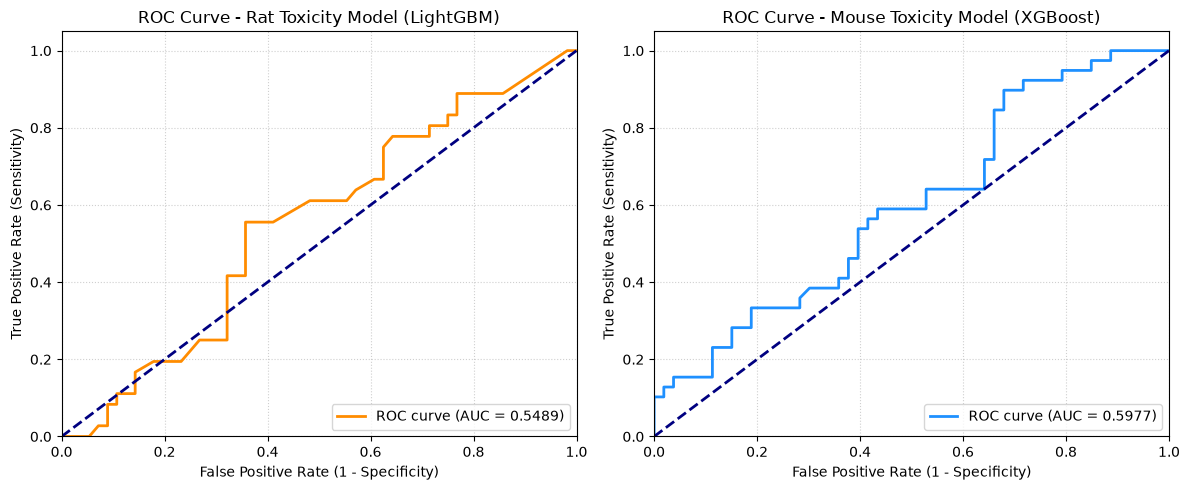

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. 종합적인 평가지표 비교 결과를 바탕으로 종별 최종 모델(Best Estimator) 추출
best_lgbm_rat = grid_lgbm_rat.best_estimator_   # Rat은 몰빵 현상을 방지하기 위해 LightGBM 채택
best_xgb_mouse = grid_xgb_mouse.best_estimator_ # Mouse는 독성 탐지력(Recall 0.64)이 우수한 XGBoost 채택

# 2. Test 데이터셋을 사용해 최종 발암성 확률 예측
rat_probs = best_lgbm_rat.predict_proba(X_rat_test)[:, 1]
mouse_probs = best_xgb_mouse.predict_proba(X_mouse_test)[:, 1] # 최적 모델 변경 반영

# 3. ROC 커브를 그리기 위한 False Positive Rate(FPR) 및 True Positive Rate(TPR) 계산
fpr_rat, tpr_rat, _ = roc_curve(y_rat_test, rat_probs)
roc_auc_rat = auc(fpr_rat, tpr_rat)

fpr_mouse, tpr_mouse, _ = roc_curve(y_mouse_test, mouse_probs)
roc_auc_mouse = auc(fpr_mouse, tpr_mouse)

# 4. 그래프 그리기 (시각화 세팅)
plt.figure(figsize=(12, 5))

# 4-1. Rat 모델 ROC 커브 (LightGBM)
plt.subplot(1, 2, 1)
plt.plot(fpr_rat, tpr_rat, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_rat:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 무작위 예측선 (기준점)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Rat Toxicity Model (LightGBM)')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

# 4-2. Mouse 모델 ROC 커브 (XGBoost) -> 변경 완료
plt.subplot(1, 2, 2)
plt.plot(fpr_mouse, tpr_mouse, color='dodgerblue', lw=2, label=f'ROC curve (AUC = {roc_auc_mouse:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Mouse Toxicity Model (XGBoost)')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Learning Curve

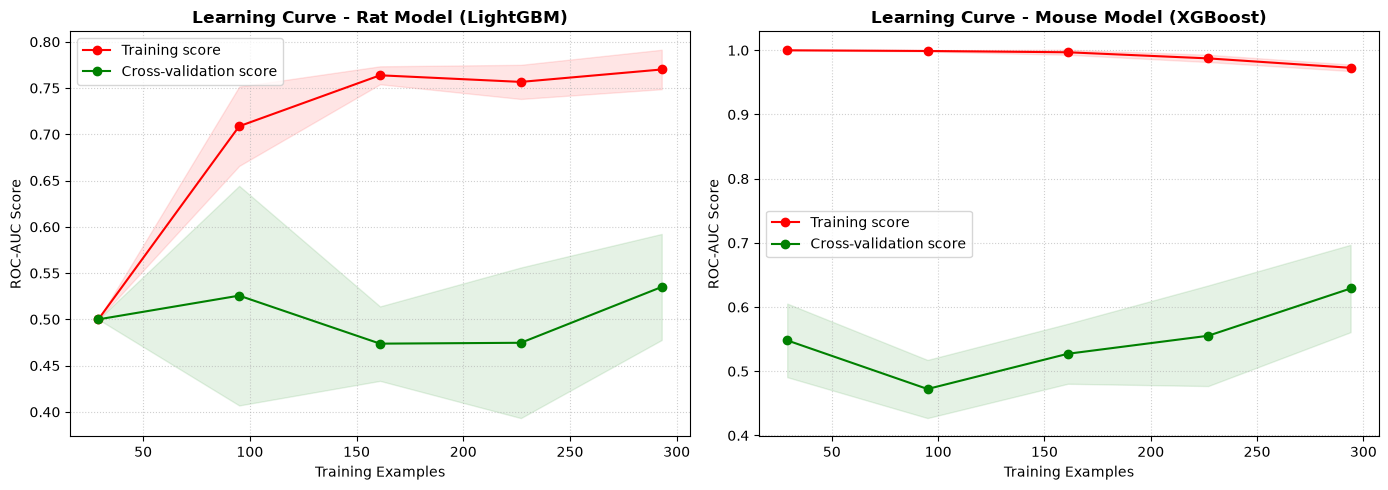

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_종별_learning_curve(estimator, X, y, title, ax):
    """
    최종 베스트 모델의 데이터 증가에 따른 Train/Validation 점수 변화(Learning Curve)를 그리는 함수
    """
    # 5-Fold CV를 적용하여 데이터셋 크기별 성능 측정
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=5,
        scoring='roc_auc', # 최적화 기준과 동일하게 설정
        n_jobs=-1,
        random_state=42
    )
    
    # 교차 검증 평균 및 표준편차 계산
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # 그래프 플로팅
    ax.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
    
    # 편차 격차 시각화 (Shading)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Training Examples", fontsize=10)
    ax.set_ylabel("ROC-AUC Score", fontsize=10)
    ax.legend(loc="best")
    ax.grid(True, linestyle=':', alpha=0.6)

# 2. 서브플롯 생성하여 종별 최종 모델 매핑
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2-1. Rat 최종 모델 (LightGBM) Learning Curve
plot_종별_learning_curve(best_lgbm_rat, X_rat_train, y_rat_train, "Learning Curve - Rat Model (LightGBM)", axes[0])

# 2-2. Mouse 최종 모델 (XGBoost) Learning Curve
plot_종별_learning_curve(best_xgb_mouse, X_mouse_train, y_mouse_train, "Learning Curve - Mouse Model (XGBoost)", axes[1])

plt.tight_layout()
plt.show()

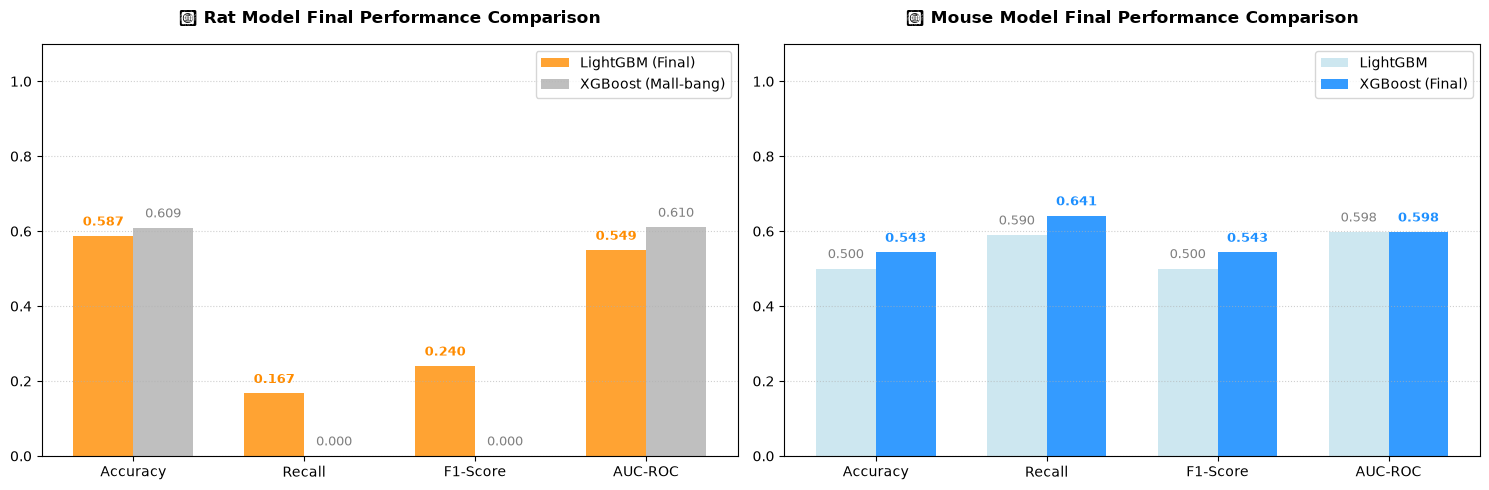

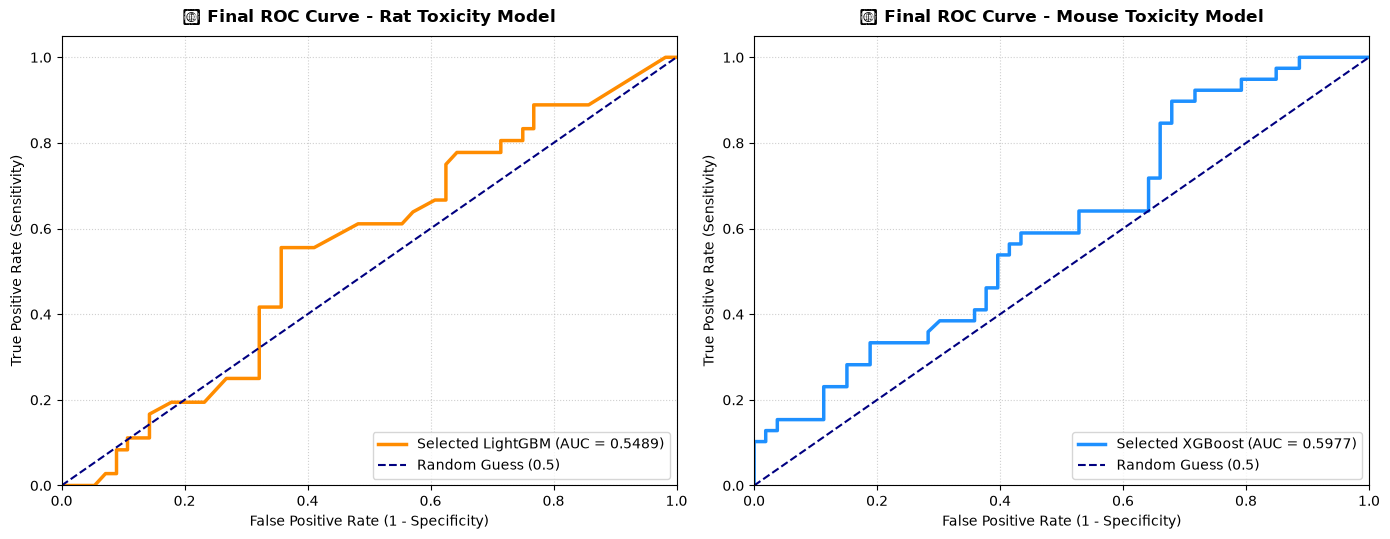

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# -------------------------------------------------------------------------
# [사전 세팅] 데이터프레임 변환 및 최종 모델 예측 확률 계산
# -------------------------------------------------------------------------
df_rat = pd.DataFrame(final_rat_results).T
df_mouse = pd.DataFrame(final_mouse_results).T

# 각 종별로 최종 채택한 베스트 모델의 예측 확률 계산
rat_probs = best_lgbm_rat.predict_proba(X_rat_test)[:, 1]     # Rat 최종: LightGBM
mouse_probs = best_xgb_mouse.predict_proba(X_mouse_test)[:, 1] # Mouse 최종: XGBoost

fpr_rat, tpr_rat, _ = roc_curve(y_rat_test, rat_probs)
roc_auc_rat = auc(fpr_rat, tpr_rat)

fpr_mouse, tpr_mouse, _ = roc_curve(y_mouse_test, mouse_probs)
roc_auc_mouse = auc(fpr_mouse, tpr_mouse)


# -------------------------------------------------------------------------
# 📊 VISUALIZATION 1. 최종 모델 주요 성능 지표 비교 (막대그래프)
# -------------------------------------------------------------------------
metrics = ['Accuracy', 'Recall', 'F1-Score', 'AUC-ROC']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1-1. Rat 모델 지표 비교 (LightGBM vs XGBoost)
x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, df_rat.loc['LightGBM (Best)', metrics], width, label='LightGBM (Final)', color='darkorange', alpha=0.8)
axes[0].bar(x + width/2, df_rat.loc['XGBoost (Best)', metrics], width, label='XGBoost (Mall-bang)', color='gray', alpha=0.5)
axes[0].set_title('💡 Rat Model Final Performance Comparison', fontsize=12, fontweight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# 값 표시 (수치 텍스트)
for i in x:
    axes[0].text(i - width/2, df_rat.loc['LightGBM (Best)', metrics[i]] + 0.02, f"{df_rat.loc['LightGBM (Best)', metrics[i]]:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkorange')
    axes[0].text(i + width/2, df_rat.loc['XGBoost (Best)', metrics[i]] + 0.02, f"{df_rat.loc['XGBoost (Best)', metrics[i]]:.3f}", ha='center', va='bottom', fontsize=9, color='gray')

# 1-2. Mouse 모델 지표 비교 (LightGBM vs XGBoost)
axes[1].bar(x - width/2, df_mouse.loc['LightGBM (Best)', metrics], width, label='LightGBM', color='lightblue', alpha=0.6)
axes[1].bar(x + width/2, df_mouse.loc['XGBoost (Best)', metrics], width, label='XGBoost (Final)', color='dodgerblue', alpha=0.9)
axes[1].set_title('💡 Mouse Model Final Performance Comparison', fontsize=12, fontweight='bold', pad=15)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

for i in x:
    axes[1].text(i - width/2, df_mouse.loc['LightGBM (Best)', metrics[i]] + 0.02, f"{df_mouse.loc['LightGBM (Best)', metrics[i]]:.3f}", ha='center', va='bottom', fontsize=9, color='gray')
    axes[1].text(i + width/2, df_mouse.loc['XGBoost (Best)', metrics[i]] + 0.02, f"{df_mouse.loc['XGBoost (Best)', metrics[i]]:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold', color='dodgerblue')

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# 📈 VISUALIZATION 2. 최종 엄선된 종별 서브 모델 ROC 커브 시각화
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 5.5))

# 2-1. Rat 최종 모델 ROC 커브 (LightGBM)
plt.subplot(1, 2, 1)
plt.plot(fpr_rat, tpr_rat, color='darkorange', lw=2.5, label=f'Selected LightGBM (AUC = {roc_auc_rat:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=10)
plt.title('🎯 Final ROC Curve - Rat Toxicity Model', fontsize=12, fontweight='bold', pad=10)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# 2-2. Mouse 최종 모델 ROC 커브 (XGBoost)
plt.subplot(1, 2, 2)
plt.plot(fpr_mouse, tpr_mouse, color='dodgerblue', lw=2.5, label=f'Selected XGBoost (AUC = {roc_auc_mouse:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=10)
plt.title('🎯 Final ROC Curve - Mouse Toxicity Model', fontsize=12, fontweight='bold', pad=10)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [24]:
import joblib

# 1. 랫드(Rat) 최종 베스트 모델(LightGBM) 저장
joblib.dump(best_lgbm_rat, 'best_model_rat_lgbm.pkl')

# 2. 마우스(Mouse) 최종 베스트 모델(XGBoost) 저장
joblib.dump(best_xgb_mouse, 'best_model_mouse_xgboost.pkl')

print("종별 최종 최적화 머신러닝 모델 파일 저장 완료!")

종별 최종 최적화 머신러닝 모델 파일 저장 완료!
